# **HW1B: Hate Speech Detection**

# Import Libraries

In [2]:
# IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/gdrive')

import json
from pathlib import Path
from collections import Counter

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split

import torch
from torchtext.vocab import build_vocab_from_iterator
from torch import nn
from torch.nn import functional as F
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import Vocab, vocab
from torch.nn.utils.rnn import pack_padded_sequence

from sklearn.metrics import accuracy_score
import time

from torch.utils.data import DataLoader
import torch.optim as optim

from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import itertools
import re

!pip install wordcloud lazypredict
from wordcloud import WordCloud

from sklearn.metrics import f1_score, recall_score, precision_score, confusion_matrix
import seaborn as sns

Mounted at /content/gdrive


# Import Data

In [3]:
train_path = Path("/content/gdrive/MyDrive/Colab Notebooks/MNLP/HW1B/anonimizzati 2/anonimizzati/Development_set/haspeede2_dev_taskAB_anon_revised.tsv")
test_news_path = Path("/content/gdrive/MyDrive/Colab Notebooks/MNLP/HW1B/anonimizzati 2/anonimizzati/Test_set/haspeede2_reference_taskAB-news_anon_revised.tsv")
test_tweets_path = Path("/content/gdrive/MyDrive/Colab Notebooks/MNLP/HW1B/anonimizzati 2/anonimizzati/Test_set/haspeede2_reference_taskAB-tweets_anon_revised.tsv")

In [4]:
# Load Train Set
train_df = pd.read_csv(train_path, sep = ",", usecols = ["full_text", "hs"])

# Load Test Set
test_news_df = pd.read_csv(test_news_path, sep = ",", usecols = ["full_text", "hs"])
test_tweets_df = pd.read_csv(test_tweets_path, sep = ",", usecols = ["full_text", "hs"])
test_df = pd.concat([test_news_df, test_tweets_df])

In [5]:
# Generate the Validation Set from the Train
train_df, val_df = train_test_split(train_df, test_size = 0.10, random_state = 42) # random state for reproducibility

In [6]:
print("Dimension of Train Set: ", train_df.shape)
print("Dimension of Validation Set: ", val_df.shape)
print("Dimension of Test Set: ", test_df.shape)

Dimension of Train Set:  (6155, 2)
Dimension of Validation Set:  (684, 2)
Dimension of Test Set:  (1763, 2)


# Exploratory data analysis (EDA)

In [7]:
def plot_labels_count(labels, name_type):
  labels = labels.to_frame()
  plt.figure(figsize=(8, 5))
  ax = labels["hs"].value_counts().plot(kind = "bar", color = ["#007BA7", "#99CBFF"])
  ax.set_title(f"Labels Count in {name_type} Set")
  ax.set_xlabel("Lables")
  ax.set_xticklabels(["odio", "neutrale"], rotation = 0)
  ax.set_ylabel("Count")
  ax.grid()
  plt.show()


def plot_distro_sentence_len(text, name_type):
  text = text.to_frame()
  lens = list(text['full_text'].apply(len))
  plt.hist(lens, bins = 30, color = "#99CBFF", edgecolor = "black")
  plt.title(f"Distribution of Sentence Lengths in {name_type} Set")
  plt.xlabel("Sentence Length")
  plt.ylabel("Frequency")
  plt.show()


def generate_wordcloud(df, columtextname):
  fig, axs = plt.subplots(1,2 , figsize=(16,8))
  text_pos = " ".join(df[columtextname][df.hs == 0])
  text_neg = " ".join(df[columtextname][df.hs == 1])
  cloud_pos = WordCloud(collocations = False, background_color = 'white').generate(text_pos)
  cloud_neu = WordCloud(collocations = False, background_color = 'lightblue').generate(text_neg)
  axs[0].imshow(cloud_pos, interpolation='bilinear')
  axs[0].axis('off')
  axs[0].set_title("Commenti neutrali")
  axs[1].imshow(cloud_neu, interpolation='bilinear')
  axs[1].axis('off')
  axs[1].set_title("Commenti d'odio")

  plt.show()

def find_most_common_words(df, column_name, n):
  all_text = ' '.join(df[column_name].astype(str))
  words = all_text.split()
  word_counts = Counter(words)
  most_common_words = word_counts.most_common(n)
  return most_common_words

def clean_data(text):
  tokens = text.split()
  filtered_tokens = [word for word in tokens if word not in stop_words]
  return ' '.join(filtered_tokens)

In [8]:
unique_df = pd.concat([train_df, val_df, test_df])
most_common_words_neutral = find_most_common_words(unique_df[unique_df.hs == 0], "full_text", 30)
print("30 most common neutral words: ")
most_common_words_neutral

30 most common neutral words: 


[('URL', 2996),
 ('di', 2950),
 ('@user', 2724),
 ('e', 2541),
 ('a', 1886),
 ('i', 1796),
 ('che', 1776),
 ('in', 1466),
 ('il', 1393),
 ('la', 1389),
 ('per', 1345),
 ('non', 1144),
 ('è', 978),
 ('un', 959),
 ('rom', 822),
 ('della', 699),
 ('sono', 661),
 ('con', 654),
 ('gli', 639),
 ('migranti', 637),
 ('le', 604),
 ('dei', 590),
 ('si', 559),
 ('da', 554),
 ('del', 548),
 ('una', 463),
 ('al', 447),
 ('ha', 416),
 ('alla', 389),
 ('anche', 378)]

In [9]:
most_common_words_hate = find_most_common_words(unique_df[unique_df.hs == 1], "full_text", 30)
print("30 most common hate words: ")
most_common_words_hate

30 most common hate words: 


[('@user', 2851),
 ('e', 2316),
 ('di', 2177),
 ('che', 1841),
 ('i', 1522),
 ('a', 1499),
 ('in', 1153),
 ('non', 1129),
 ('URL', 1073),
 ('la', 1035),
 ('il', 982),
 ('per', 885),
 ('è', 839),
 ('gli', 715),
 ('sono', 704),
 ('un', 613),
 ('le', 579),
 ('da', 572),
 ('con', 569),
 ('tutti', 525),
 ('si', 516),
 ('immigrati', 425),
 ('ci', 409),
 ('loro', 400),
 ('E', 390),
 ('una', 384),
 ('I', 361),
 ('migranti', 347),
 ('dei', 334),
 ('del', 311)]

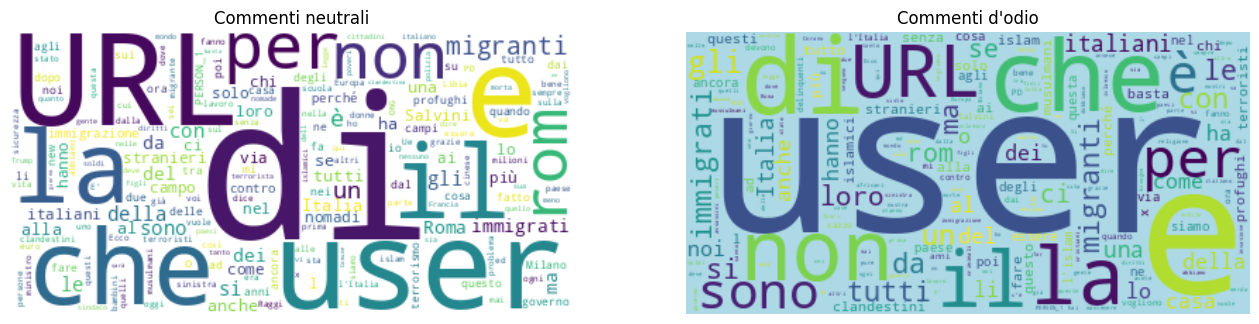

In [10]:
generate_wordcloud(unique_df, "full_text")

In [11]:
stop_words_path = Path("/content/gdrive/MyDrive/Colab Notebooks/MNLP/HW1B/stop_words_italian.txt")
stop_words = []
with open(stop_words_path, "r") as f:
   for line in f:
     stop_words.append(line.strip())

print("Number of stopwords: ", len(stop_words), "\n")
print("Preview of 20 stopwords: ")
stop_words[:20]

Number of stopwords:  132 

Preview of 20 stopwords: 


['a',
 'adesso',
 'ai',
 'al',
 'alla',
 'allo',
 'allora',
 'altre',
 'altri',
 'altro',
 'anche',
 'ancora',
 'avere',
 'aveva',
 'avevano',
 'ben',
 'buono',
 'che',
 'chi',
 'cinque']

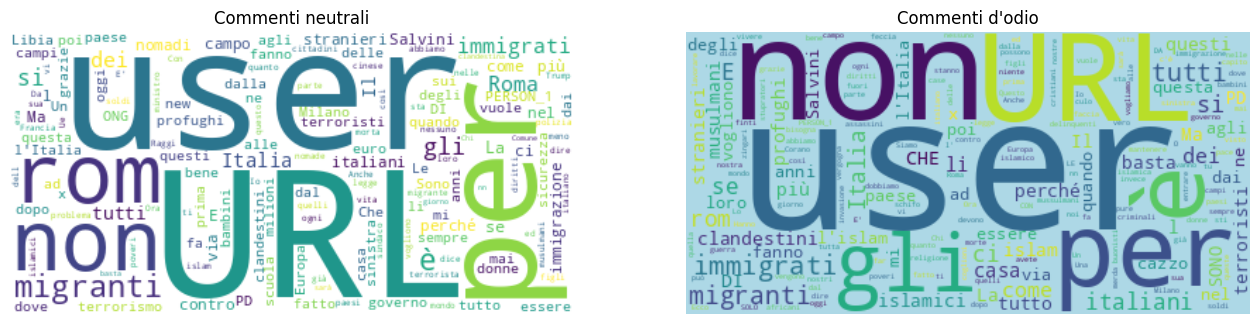

In [12]:
unique_df["filtered_full_text"] = unique_df["full_text"].apply(clean_data)
generate_wordcloud(unique_df, "filtered_full_text")

## Training Set EDA

In [13]:
display(train_df.head())

,full_text,hs
4996,@user @user Ben detto! Peccato che l’Islam lo ...,0
1407,#dimartedi Stasera indlttrinamento pro Europa....,0
3535,Bambine di dieci anni imbottite di esplosivo e...,1
4763,Nasce la nuova Procura UE. Potrebbe decidere s...,0
6155,La cosa più aberrante del #GlobalCompact ❓ Sa...,0


In [14]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6155 entries, 4996 to 860
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  6155 non-null   object
 1   hs         6155 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 144.3+ KB


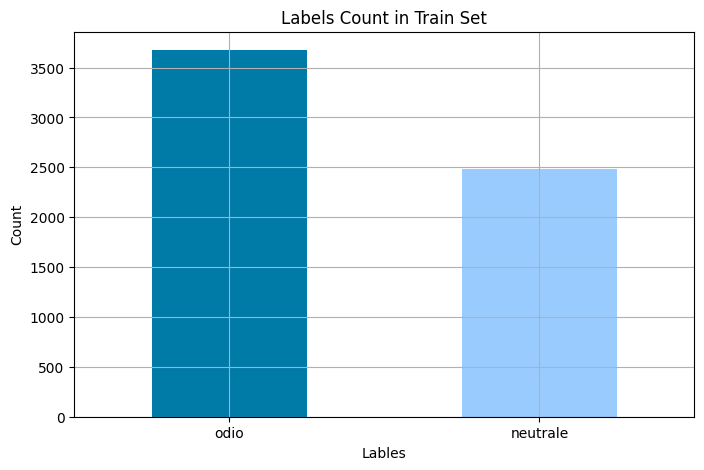

In [15]:
plot_labels_count(train_df['hs'], "Train")

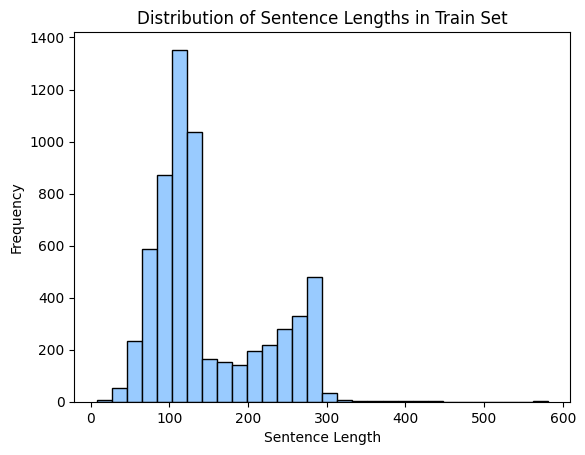

In [16]:
plot_distro_sentence_len(train_df['full_text'], "Train")

## Test Set EDA

In [17]:
display(test_df.head())

,full_text,hs
0,"""Andate pure là, tanto quei fessi degli italia...",1
1,"""Che fine spero che faccia il killer nigeriano...",1
2,"""Così i profughi ci svuotano i negozi a Porden...",1
3,"""Così umiliano gli italiani e coccolano i clan...",1
4,"""Danno soldi ai clandestini, ma ai disabili in...",1


In [18]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1763 entries, 0 to 1262
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  1763 non-null   object
 1   hs         1763 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 41.3+ KB


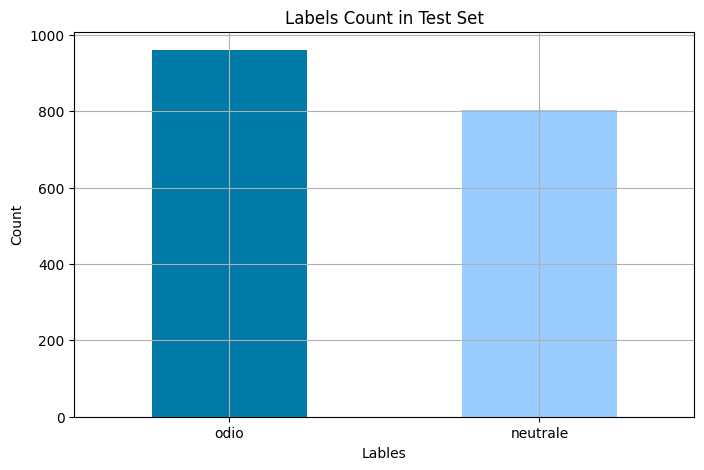

In [19]:
plot_labels_count(test_df["hs"], "Test")

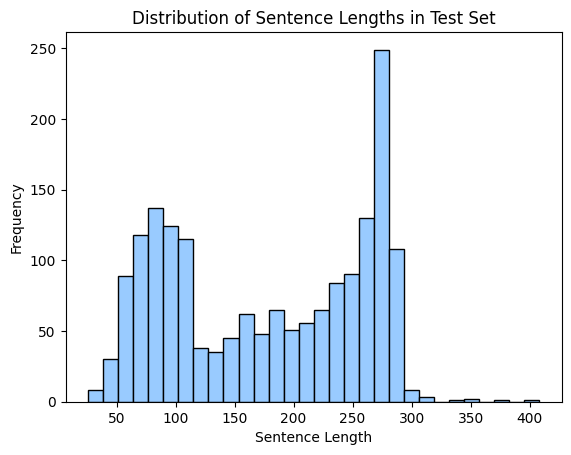

In [20]:
plot_distro_sentence_len(test_df["full_text"], "Test")

## Validation Set EDA

In [21]:
display(val_df.head())

,full_text,hs
3238,#dallavostraparte Ha fatto bene il ristoratore...,1
3706,quanti morti ci devono ancora essere prima di ...,1
435,IL musulmano e un individuo che si sottom...,0
5659,"Dobbiamo aiutare i NOSTRI ITALIANI, senza casa...",1
3418,@user @user @user @user saremo invasi da musul...,1


In [22]:
val_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 684 entries, 3238 to 3630
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  684 non-null    object
 1   hs         684 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 16.0+ KB


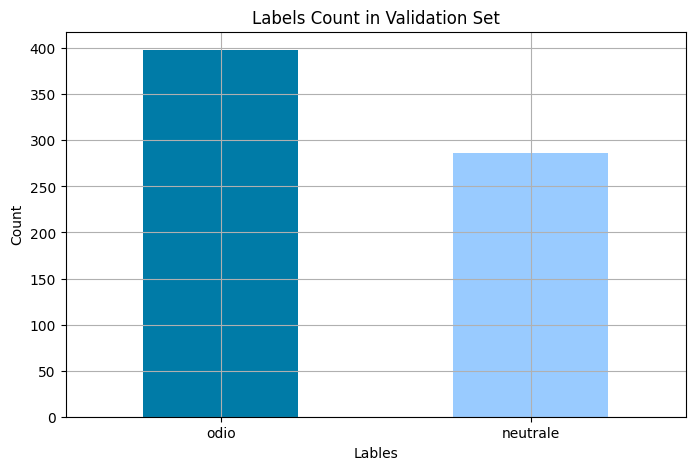

In [23]:
plot_labels_count(val_df["hs"], "Validation")

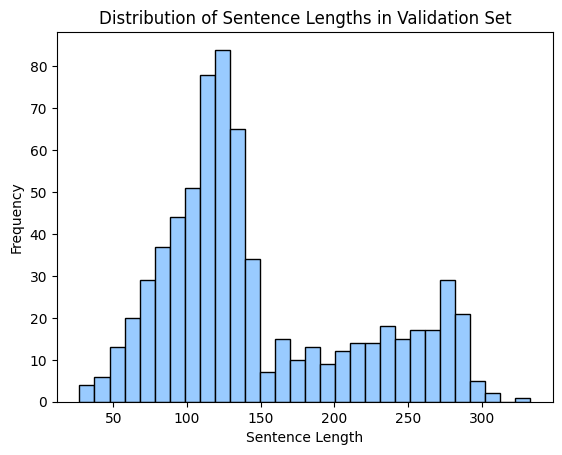

In [24]:
plot_distro_sentence_len(val_df["full_text"], "Validation")

# Data Preparation

In [25]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
device

device(type='cuda')

In [26]:
def save_jsonl(df, output_path):
  with open(output_path, "w") as output_file:
    for i, rows in df.iterrows():
      reformatted_jsonl_data = {
          'id' : i,
          "text" : rows['full_text'],
          "choices": ["odio", "neutrale"],
          "label" : int(rows['hs'])
      }
      json.dump(reformatted_jsonl_data, output_file)
      output_file.write("\n")

In [27]:
# Train Set JSONL
save_jsonl(train_df, "HaSpeeDe2_taskA-train.jsonl")
!head "HaSpeeDe2_taskA-train.jsonl" # preview of the first 10 lines

{"id": 4996, "text": "@user @user Ben detto! Peccato che l\u2019Islam lo predichi da sempre...copia anche Bergoglio? Oppure cerca un avvicinamento con la religione di pace e amore? ", "choices": ["odio", "neutrale"], "label": 0}
{"id": 1407, "text": "#dimartedi Stasera indlttrinamento pro Europa.Alla bisogna sono benvenuti anche gli stranieri.Bravo #Floris,vai a cager ", "choices": ["odio", "neutrale"], "label": 0}
{"id": 3535, "text": "Bambine di dieci anni imbottite di esplosivo e fatte esplodere, anche questo \u00e8 #islamistheproblem #IslamicState Islam ", "choices": ["odio", "neutrale"], "label": 1}
{"id": 4763, "text": "Nasce la nuova Procura UE. Potrebbe decidere su Italia e immigrazione URL ", "choices": ["odio", "neutrale"], "label": 0}
{"id": 6155, "text": "La cosa pi\u00f9 aberrante del #GlobalCompact \u2753  Sar\u00e0 REATO parlare di #immigrazione - #migranti   \"SOPPRESSA PER LEGGE LA LIBERTA' D'OPINIONE\"  Ora sapete perch\u00e9 le elites #sorosiane lo vogliono, vogliono

In [28]:
# Validation Set JSONL
save_jsonl(test_df, "HaSpeeDe2_taskA-test.jsonl")
!head "HaSpeeDe2_taskA-test.jsonl" # preview of the first 10 lines

{"id": 0, "text": "\"Andate pure l\u00e0, tanto quei fessi degli italiani...\". Capito perch\u00e9 ci invadono? Il clandestino confessa", "choices": ["odio", "neutrale"], "label": 1}
{"id": 1, "text": "\"Che fine spero che faccia il killer nigeriano di Pamela\". La furia cieca della Meloni: le sue parole pi\u00f9 dure", "choices": ["odio", "neutrale"], "label": 1}
{"id": 2, "text": "\"Cos\u00ec i profughi ci svuotano i negozi a Pordenone\"", "choices": ["odio", "neutrale"], "label": 1}
{"id": 3, "text": "\"Cos\u00ec umiliano gli italiani e coccolano i clandestini\". La follia del governo: \"Per loro gratis...\", e ci invadono", "choices": ["odio", "neutrale"], "label": 1}
{"id": 4, "text": "\"Danno soldi ai clandestini, ma ai disabili invece...\". Bracconeri, il figlio autistico e il durissimo sfogo a \"Libero\"", "choices": ["odio", "neutrale"], "label": 1}
{"id": 5, "text": "\"Emergenza, Minniti annulla il viaggio e torna in Italia\". Immigrati, invasione alle porte: cose mai viste p

In [29]:
# Validation Set JSONL
save_jsonl(val_df, "HaSpeeDe2_taskA-val.jsonl")
!head "HaSpeeDe2_taskA-val.jsonl" # preview of the first 10 lines

{"id": 3238, "text": "#dallavostraparte Ha fatto bene il ristoratore dare cena a soli italiani, sono i pi\u00f9 bisognosi rispetto ai migranti che il Gov.PD da tutto. ", "choices": ["odio", "neutrale"], "label": 1}
{"id": 3706, "text": "quanti morti ci devono ancora essere prima di capire che l'immigrazione islamica e africana \u00e8 un cancro? #stopimmigrazione #stopislam ", "choices": ["odio", "neutrale"], "label": 1}
{"id": 435, "text": "IL musulmano   e un individuo  che  si  sottomette. Alla volonta  dell'unico vero  dio(Allah) ,il creatore ", "choices": ["odio", "neutrale"], "label": 0}
{"id": 5659, "text": "Dobbiamo aiutare i NOSTRI ITALIANI, senza casa, lavoro, aiuti..Quanti clandestini o immigrati sono andati a pulire strade e argini di fiumi o torrenti in questi giorni tragici PER molte  regioni italiane ?! Guadagnarsi il  pane no eh ?? PARASSITI!! URL ", "choices": ["odio", "neutrale"], "label": 1}
{"id": 3418, "text": "@user @user @user @user saremo invasi da musulmani che 

In [30]:
# Tokenizer and an example of how it works
tokenizer = get_tokenizer('basic_english')

random_text = train_df["full_text"][5]
print("Example: ", random_text, "\n")
print("Data Tokenization: ")
tokenizer(random_text)

Example:  Modena: Comune paga la benzina ai nomadi che portano figli a scuola: MODENA – La giunta PD… URL  

Data Tokenization: 


['modena',
 'comune',
 'paga',
 'la',
 'benzina',
 'ai',
 'nomadi',
 'che',
 'portano',
 'figli',
 'a',
 'scuola',
 'modena',
 '–',
 'la',
 'giunta',
 'pd…',
 'url']

In [31]:
pad_token, unk_token = "<pad>", "<unk>"

class HaSpeeDeDataset(Dataset):
    def __init__(
        self,
        input_file: Path,
        max_length: int = 500,
        device: str = "cuda",
        preprocessing: bool = False,
        stop_words: set[str] | None = None,
    ):

        self.samples = []
        self.device = torch.device(device)
        self.max_lenght = max_length
        self.tokenizer = get_tokenizer("basic_english")
        self.preprocessing = preprocessing
        self.stop_words = stop_words if stop_words else set()

        self.indexed_data: list[dict] | None = None
        self.padding_id: int | None = None


        with open(input_file, "r") as f:
            for line in f:
                sample = json.loads(line.strip())
                if self.preprocessing == True:
                  sample["text"] = self.text_preprocessing(sample["text"])
                sample["tokens"] = tokenizer(sample["text"])
                self.samples.append(sample)

    # Peprocessing Function
    def text_preprocessing(self, text: str) -> str:
      tokens = self.tokenizer(text)
      preprocessed_tokens = [token.lower() for token in tokens if token.lower() not in self.stop_words]
      pattern = pattern = r'[^\w\s]'
      result = re.sub(pattern, '', ' '.join(preprocessed_tokens))
      return result

    def get_raw_element(self, idx: int) -> dict:
        return self.samples[idx]

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int) -> dict:
        return self.indexed_data[idx]

    def get_vocabulary(
        self,
        pad_token: str = "<pad>",
        unk_token: str = "<unk>",
        extra_tokens: list[str] = []
    ) -> Vocab:
        vocab_counter = dict(Counter(token for sent in self.samples for token in sent["tokens"]).most_common())
        vocabulary = vocab(vocab_counter, specials=[pad_token, unk_token, *extra_tokens], min_freq=1)
        vocabulary.set_default_index(vocabulary([unk_token])[0])
        return vocabulary

    def set_padding_id(self, value: int) -> None:
        self.padding_id = value

    def index(self, vocabulary: Vocab) -> None:
        if self.indexed_data is not None:
            print("Dataset has already been indexed. Keeping old index...")
        else:
            indexed_data = []
            for sample in self.samples:
                indexed_data.append({"input_ids": vocabulary(sample["tokens"]), "label": sample["label"]})
            self.indexed_data = indexed_data

    def _collate_fn(self, raw_batch: list[dict]) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        sequence_lengths = torch.tensor([len(sample["input_ids"]) for sample in raw_batch], dtype=torch.long)
        padded_sequence = pad_sequence(
            (
                torch.tensor(sample["input_ids"], dtype=torch.long, device=self.device)
                for sample in raw_batch
            ),
            batch_first=True,
            padding_value=self.padding_id
        )
        labels = torch.tensor([sample["label"] for sample in raw_batch], device=self.device, dtype=torch.long)
        return sequence_lengths, padded_sequence, labels

# Data Modeling

## Dummy Classifier

In [32]:
# Stratified strategy randomly chooses class labels based on the class distribution in the Training set
dummy_model = DummyClassifier(strategy='stratified', random_state=42)

# Train the DummyClassifier
dummy_model.fit(train_df["full_text"], train_df["hs"])

DummyClassifier(random_state=42, strategy='stratified')

### Dummy Classifier Performance Evaluation

Statistics for Dummy Classifier
Validation Accuracy:  0.5
Test Accuracy: 0.5
Test Precision: 0.44
Test Recall: 0.39
Test F1-score: 0.42
 


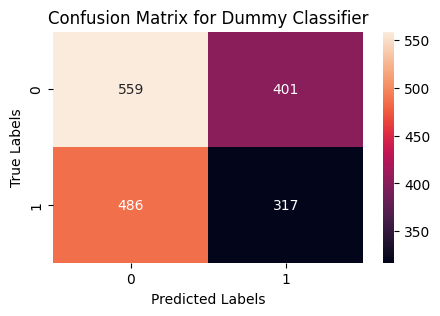

In [33]:
# Evaluating accuracy for Validation Set
baseline_val_y_pred = dummy_model.predict(val_df["full_text"])
baseline_val_accuracy = accuracy_score(val_df["hs"], baseline_val_y_pred)

# Performance Evaluation for Test Set
baseline_test_y_pred = dummy_model.predict(test_df["full_text"])
baseline_test_accuracy = accuracy_score(test_df["hs"], baseline_test_y_pred)
baseline_test_f1 = f1_score(test_df["hs"], baseline_test_y_pred)
baseline_test_recall = recall_score(test_df["hs"], baseline_test_y_pred)
baseline_test_precision = precision_score(test_df["hs"], baseline_test_y_pred)
baseline_test_cf = confusion_matrix(test_df["hs"], baseline_test_y_pred)


print("Statistics for Dummy Classifier")
print("Validation Accuracy: ", round(baseline_test_accuracy, 2))
print(f"Test Accuracy: {round(baseline_test_accuracy, 2)}")
print(f"Test Precision: {round(baseline_test_precision, 2)}")
print(f"Test Recall: {round(baseline_test_recall, 2)}")
print(f"Test F1-score: {round(baseline_test_f1, 2)}")

print(" ")
fig, ax = plt.subplots(figsize=(5, 3))
sns.heatmap(baseline_test_cf, annot = True, fmt = '.0f')
ax.set_title(f'Confusion Matrix for Dummy Classifier')
ax.set_xlabel('Predicted Labels')
ax.set_ylabel('True Labels')
plt.show()

## 3. BiLSTM Model

In [34]:
class BiLSTMModel(torch.nn.Module):

    def __init__(
        self,
        vocabulary_length: int,
        hidden_dim: int,
        bilstm_layers: int,
        num_classes: int,
        padding_id: int,
        dropout : float,
        weight_decay: float = 0.01,
        device: str = "cuda",
    ) -> None:
        super().__init__()

        # Prepare the device
        self.device = torch.device(device)

        # Embedding Layer
        self.embedding = nn.Embedding(
            num_embeddings = vocabulary_length,
            embedding_dim = hidden_dim,
            padding_idx = padding_id,
            device = self.device
        )

        # BiLSTM Model
        self.bilstm = nn.LSTM(
            input_size = hidden_dim,
            hidden_size = hidden_dim,
            num_layers = bilstm_layers,
            batch_first = True,
            dropout = dropout,
            bidirectional = True,
            device = self.device
        )

        # Droupout Layer
        self.dropout = nn.Dropout(p=0.3)

        # Batch Normalization
        self.batchnorm = nn.BatchNorm1d(hidden_dim*2, device = device)

        # Projection Layers
        self.projection = nn.Linear(
            in_features = hidden_dim * 2,
            out_features = num_classes,
            device = device
        )

        # L2 Regularization
        self.projection.weight_decay = weight_decay

        # Activation Function
        self.sigmoid = nn.Sigmoid()


    def forward(self, batch: tuple[torch.Tensor, torch.Tensor]) -> torch.Tensor:
      sequence_lengths, input_ids = batch
      embeds = self.embedding(input_ids)
      embeds = self.dropout(embeds)
      packed = pack_padded_sequence(embeds, sequence_lengths.cpu(), batch_first=True, enforce_sorted=False)
      packed_output, (hidden_state, cell_state) = self.bilstm(packed)
      hidden = torch.cat((hidden_state[-2,:,:], hidden_state[-1,:,:]), dim=1)
      normalized = self.batchnorm(hidden)
      logits = self.projection(hidden)
      output = self.sigmoid(logits)
      return output

In [35]:
class Trainer():
    """Utility class to train and evaluate a model."""

    def __init__(
        self,
        model: nn.Module,
        optimizer: torch.optim.Optimizer = torch.optim.Adam,
        criterion: nn.Module = nn.CrossEntropyLoss(),
        lr: float = 0.001
    ):
        self.model = model
        self.optimizer = optimizer(self.model.parameters(), lr=lr)
        self.criterion = criterion

    def train(self, train_dataloader: DataLoader, valid_dataloader: DataLoader, epochs: int = 1, verbose: bool = False) -> dict[str, list[float]]:
        counter = 0
        deltas = []
        losses = {
            "train_losses": [],
            "train_acc": [],
            "valid_losses": [],
            "valid_acc": []
        }

        for epoch in range(1, epochs + 1):
            epoch_loss = 0.0
            self.model.train()

            for step, (sequence_lengths, inputs, labels) in enumerate(train_dataloader):
                self.optimizer.zero_grad()
                predictions = self.model((sequence_lengths, inputs))
                sample_loss = self.criterion(predictions, labels)
                sample_loss.backward()
                self.optimizer.step()

                epoch_loss += sample_loss.cpu().tolist()

            avg_epoch_loss = epoch_loss / len(train_dataloader)
            valid_loss, valid_acc, _, _, _, _ = self.evaluate(valid_dataloader)

            if verbose:
              print('-' * 90)
              print(f"| end of epoch {epoch:3d} | train loss {avg_epoch_loss:8.3f} | valid accuracy {valid_acc:8.3f} | valid loss {valid_acc:8.3f}")
              print('-' * 90)

            losses["train_losses"].append(avg_epoch_loss)
            losses["valid_losses"].append(valid_loss)
            losses["valid_acc"].append(valid_acc)

            # Early Stopping strategy
            deltas.append(valid_loss - avg_epoch_loss)
            if (valid_loss - avg_epoch_loss) > deltas[-1]:
                counter += 1
                if counter >= 3:
                    break

        return losses

    def _compute_acc(self, logits: torch.Tensor, labels: torch.Tensor) -> float:
        predictions = torch.argmax(logits, dim=1)
        return torch.mean((predictions == labels).float()).tolist()

    def _compute_metrics(self, logits: torch.Tensor, labels: torch.Tensor) -> tuple[float, float, float]:
        predictions = torch.argmax(logits, dim=1).cpu().numpy()
        labels = labels.cpu().numpy()
        f1 = f1_score(labels, predictions, average = 'weighted', zero_division = 0)
        recall = recall_score(labels, predictions, average = 'weighted', zero_division = 0)
        precision = precision_score(labels, predictions, average = 'weighted', zero_division = 0)
        return f1, recall, precision

    def evaluate(self, dataloader: DataLoader) -> tuple[float, float, float, float, float, np.ndarray]:
        loss = 0.0
        acc = 0.0
        f1 = 0.0
        recall = 0.0
        precision = 0.0
        confusion_matrix_all = np.zeros((2, 2))

        self.model.eval()
        with torch.no_grad():
            for batch in dataloader:
                sequence_lengths, inputs, labels = batch

                logits = self.model((sequence_lengths, inputs))
                sample_loss = self.criterion(logits, labels)
                loss += sample_loss.tolist()

                sample_acc = self._compute_acc(logits, labels)
                acc += sample_acc

                sample_f1, sample_recall, sample_precision = self._compute_metrics(logits, labels)
                f1 += sample_f1
                recall += sample_recall
                precision += sample_precision

                predictions = torch.argmax(logits, dim=1).cpu().numpy()
                labels = labels.cpu().numpy()
                confusion_matrix_all += confusion_matrix(labels, predictions)

        num_batches = len(dataloader)
        return loss / num_batches, acc / num_batches, f1 / num_batches, recall / num_batches, precision / num_batches, confusion_matrix_all

    def predict(self, batch: tuple[torch.Tensor, torch.Tensor]) -> tuple[torch.Tensor, torch.Tensor]:
        self.model.eval()
        with torch.no_grad():
            sequence_lengths, inputs = batch
            logits = self.model(sequence_lengths, inputs)
            predictions = torch.argmax(logits, -1)
            return logits, predictions


### Hyperparameters Optimization

In [36]:
best_results = []
best_params = {}

param_dict = {
    "preprocessing": [True, False],
    "batch_size": [64, 128, 256],
    "hidden_dim": [128, 256],
    "lr": [0.01, 0.001],
    }

for preprocessing, batch_size, hidden_dim, lr in itertools.product(*param_dict.values()):

  train_dataset = HaSpeeDeDataset(
    input_file = "/content/HaSpeeDe2_taskA-train.jsonl",
    device = device,
    preprocessing = preprocessing,
    stop_words = stop_words
    )

  test_dataset = HaSpeeDeDataset(
      input_file = "/content/HaSpeeDe2_taskA-test.jsonl",
      device = device,
      preprocessing = preprocessing,
      stop_words = stop_words)

  validation_dataset = HaSpeeDeDataset(
      input_file = "/content/HaSpeeDe2_taskA-val.jsonl",
      device = device,
      preprocessing = preprocessing,
      stop_words = stop_words)

  vocabulary = train_dataset.get_vocabulary(pad_token = pad_token, unk_token = unk_token)
  padding_id = vocabulary([pad_token])[0]


  training_dataloader = DataLoader(train_dataset, batch_size = batch_size,
                                   shuffle=False, collate_fn = train_dataset._collate_fn)

  validation_dataloader = DataLoader(validation_dataset, batch_size = batch_size,
                                     shuffle=False, collate_fn=validation_dataset._collate_fn)

  test_dataloader = DataLoader(test_dataset, batch_size=batch_size,
                               shuffle=False, collate_fn=test_dataset._collate_fn)

  train_dataset.set_padding_id(padding_id)
  validation_dataset.set_padding_id(padding_id)
  test_dataset.set_padding_id(padding_id)

  train_dataset.index(vocabulary)
  validation_dataset.index(vocabulary)
  test_dataset.index(vocabulary)

  hate_speech_detector = BiLSTMModel(
        vocabulary_length = len(vocabulary),
        hidden_dim = hidden_dim,
        bilstm_layers = 2,
        num_classes = 2,
        dropout = 0.3,
        padding_id = padding_id,
        device = device
  )

  trainer = Trainer(
        model = hate_speech_detector,
        lr = lr
  )

  losses = trainer.train(training_dataloader, validation_dataloader, epochs = 20)
  test_loss, test_acc, _, _, _, _ = trainer.evaluate(test_dataloader)

  print(f"Parameters: preprocessing = {preprocessing}, batch_size = {batch_size}, hidden_dim = {hidden_dim}, lr = {lr}")
  print(f"Test Accuracy: {round(test_acc, 3)}, Test Loss : {round(test_loss, 3)} \n")

  if round(test_acc,2) > 0.68:
    best_params = {
            "accuracy: ": test_acc,
            "loss": test_loss,
            "preprocessing": preprocessing,
            "batch_size": batch_size,
            "hidden_dim": hidden_dim,
            "lr": lr,
        }
    best_results.append(best_params)

Parameters: preprocessing = True, batch_size = 64, hidden_dim = 128, lr = 0.01
Test Accuracy: 0.704, Test Loss : 0.606 

Parameters: preprocessing = True, batch_size = 64, hidden_dim = 128, lr = 0.001
Test Accuracy: 0.666, Test Loss : 0.637 

Parameters: preprocessing = True, batch_size = 64, hidden_dim = 256, lr = 0.01
Test Accuracy: 0.715, Test Loss : 0.592 

Parameters: preprocessing = True, batch_size = 64, hidden_dim = 256, lr = 0.001
Test Accuracy: 0.673, Test Loss : 0.63 

Parameters: preprocessing = True, batch_size = 128, hidden_dim = 128, lr = 0.01
Test Accuracy: 0.665, Test Loss : 0.643 

Parameters: preprocessing = True, batch_size = 128, hidden_dim = 128, lr = 0.001
Test Accuracy: 0.705, Test Loss : 0.6 

Parameters: preprocessing = True, batch_size = 128, hidden_dim = 256, lr = 0.01
Test Accuracy: 0.68, Test Loss : 0.627 

Parameters: preprocessing = True, batch_size = 128, hidden_dim = 256, lr = 0.001
Test Accuracy: 0.674, Test Loss : 0.625 

Parameters: preprocessing = 

In [37]:
best_result = sorted(best_results, key=lambda x: (x['loss']))[0]
print("Best Parameters: ")
print(best_result)

Best Parameters: 
{'accuracy: ': 0.7152423475469861, 'loss': 0.5924095798815999, 'preprocessing': True, 'batch_size': 64, 'hidden_dim': 256, 'lr': 0.01}


### Final Model

In [38]:
train_dataset = HaSpeeDeDataset(
    input_file = "/content/HaSpeeDe2_taskA-train.jsonl",
    device = device,
    preprocessing = best_result['preprocessing'],
    stop_words = stop_words
    )

test_dataset = HaSpeeDeDataset(
    input_file = "/content/HaSpeeDe2_taskA-test.jsonl",
    device = device,
    preprocessing = best_result['preprocessing'],
    stop_words = stop_words)

validation_dataset = HaSpeeDeDataset(
    input_file = "/content/HaSpeeDe2_taskA-val.jsonl",
    device = device,
    preprocessing = best_result['preprocessing'],
    stop_words = stop_words)

vocabulary = train_dataset.get_vocabulary(pad_token = pad_token, unk_token = unk_token)
padding_id = vocabulary([pad_token])[0]

print("Number of words in the vocabulary: ", len(vocabulary))

Number of words in the vocabulary:  17570


In [39]:
train_dataset.set_padding_id(padding_id)
validation_dataset.set_padding_id(padding_id)
test_dataset.set_padding_id(padding_id)

train_dataset.index(vocabulary)
validation_dataset.index(vocabulary)
test_dataset.index(vocabulary)

print(f"Training len: {len(train_dataset)}")
print(f"Validation len: {len(validation_dataset)}")
print(f"Test len: {len(test_dataset)}")

training_dataloader = DataLoader(train_dataset, batch_size=best_result['batch_size'],
                                 shuffle=False, collate_fn=train_dataset._collate_fn)

validation_dataloader = DataLoader(validation_dataset, batch_size=best_result['batch_size'],
                                   shuffle=False, collate_fn=validation_dataset._collate_fn)

test_dataloader = DataLoader(test_dataset, batch_size=best_result['batch_size'],
                             shuffle=False, collate_fn=test_dataset._collate_fn)

Training len: 6155
Validation len: 684
Test len: 1763


In [40]:
print('Train Dataset:')
for i in range(10):
  t = train_dataset.get_raw_element(i)
  if t is not None:
    print(f'sample {i}: {t["label"]}:{t["text"]}')

Train Dataset:
sample 0: 0:user user detto  peccato lislam predichi sempre    copia bergoglio  oppure cerca avvicinamento religione pace amore 
sample 1: 0:dimartedi stasera indlttrinamento pro europa  bisogna benvenuti gli stranieri  bravo floris  cager
sample 2: 1:bambine dieci anni imbottite esplosivo fatte esplodere  è islamistheproblem islamicstate islam
sample 3: 0:nasce nuova procura ue  potrebbe decidere italia immigrazione url
sample 4: 0:più aberrante globalcompact  sarà reato parlare immigrazione  migranti soppressa per legge liberta  d  opinione sapete perché elites sorosiane vogliono  vogliono poter imporre milioni milioni primitivi ed impedire se ne parli 
sample 5: 0:i migranti sgomberati dagli edifici occupati fanno  sicuramente ministro li spedirà paesi d  origine come  non penso li abbandoni in strada peggiorare situazione sicurezza per i cittadini  qualcuno ci può dire qual è soluzione prevista
sample 6: 0:governo per cassa fai pagare tassa è in italia targa stranier

In [41]:
hate_speech_detector = BiLSTMModel(
        vocabulary_length = len(vocabulary),
        hidden_dim = best_result['hidden_dim'],
        bilstm_layers = 2,
        num_classes = 2,
        dropout = 0.3,
        padding_id = padding_id,
        device = device
    )

print(hate_speech_detector)

BiLSTMModel(
  (embedding): Embedding(17570, 256, padding_idx=0)
  (bilstm): LSTM(256, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (batchnorm): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (projection): Linear(in_features=512, out_features=2, bias=True)
  (sigmoid): Sigmoid()
)


In [42]:
BiLSTM_trainer = Trainer(
        model = hate_speech_detector,
        lr = best_result['lr']
    )

### BiLSTM Performance Evaluation

In [43]:
num_epochs = 20
BiLSTM_losses = BiLSTM_trainer.train(training_dataloader, validation_dataloader, epochs = num_epochs, verbose = True)
BiLSTM_test_loss, BiLSTM_test_acc, BiLSTM_test_f1, BiLSTM_test_recall, BiLSTM_test_precision, BiLSTM_test_cf = BiLSTM_trainer.evaluate(test_dataloader)

------------------------------------------------------------------------------------------
| end of epoch   1 | train loss    0.616 | valid accuracy    0.676 | valid loss    0.676
------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------
| end of epoch   2 | train loss    0.542 | valid accuracy    0.734 | valid loss    0.734
------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------
| end of epoch   3 | train loss    0.463 | valid accuracy    0.759 | valid loss    0.759
------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------
| end of epoch   4 | train loss    0.418 | valid accuracy    0.739 | valid loss    0.739
-------

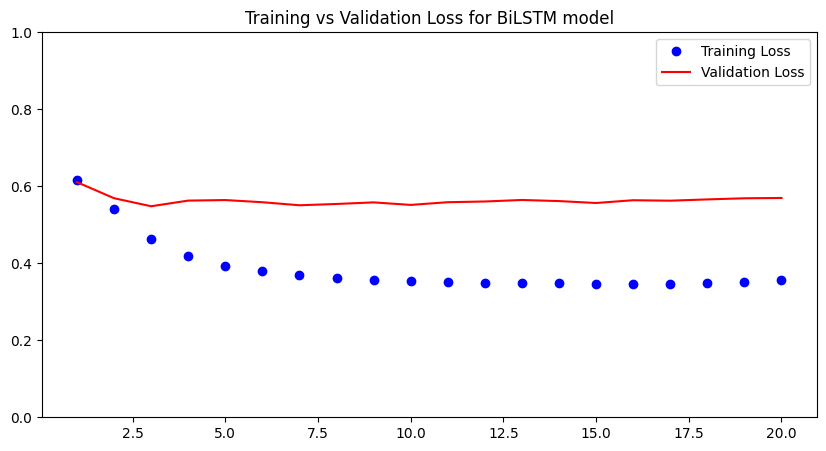

In [44]:
epochs = range(1, num_epochs + 1)
plt.figure(figsize=(10, 5))
plt.plot(epochs, BiLSTM_losses["train_losses"], 'bo', label='Training Loss')
plt.plot(epochs, BiLSTM_losses["valid_losses"], 'r', label='Validation Loss')
plt.title('Training vs Validation Loss for BiLSTM model')
plt.ylim(0, 1, emit=True)
plt.legend()
plt.show()

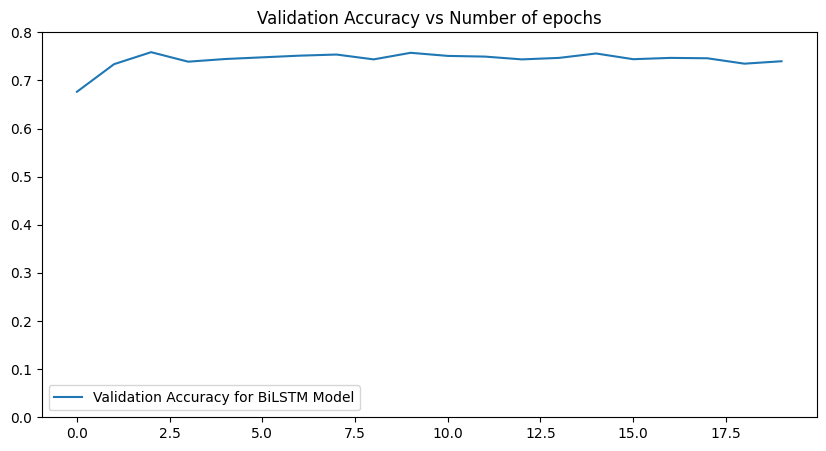

In [45]:
plt.figure(figsize=(10, 5))
plt.title("Validation Accuracy vs Number of epochs")
plt.plot(BiLSTM_losses["valid_acc"], label="Validation Accuracy for BiLSTM Model")
plt.legend()
plt.ylim(0, 0.8, emit=True)
plt.show()

Statistics for BiLSTM model
Test loss 0.6
Test accuracy: 0.72
Test Precision: 0.93
Test Recall: 0.72
Test F1-score: 0.8
 


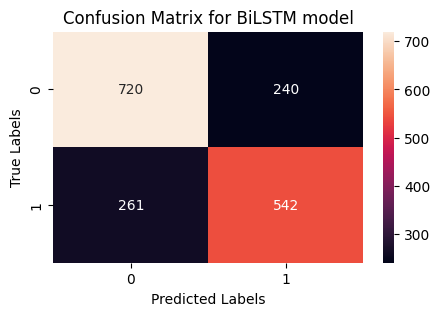

In [46]:
print("Statistics for BiLSTM model")
print(f"Test loss {round(BiLSTM_test_loss, 2)}")
print(f"Test accuracy: {round(BiLSTM_test_acc, 2)}")
print(f"Test Precision: {round(BiLSTM_test_precision, 2)}")
print(f"Test Recall: {round(BiLSTM_test_recall, 2)}")
print(f"Test F1-score: {round(BiLSTM_test_f1, 2)}")

print(" ")
fig, ax = plt.subplots(figsize=(5, 3))
sns.heatmap(BiLSTM_test_cf, annot = True, fmt = '.0f')
ax.set_title(f'Confusion Matrix for BiLSTM model')
ax.set_xlabel('Predicted Labels')
ax.set_ylabel('True Labels')
plt.show()

## RNN Model

In [47]:
class RNNModel(torch.nn.Module):

    def __init__(
        self,
        vocabulary_length: int,
        hidden_dim: int,
        num_classes: int,
        padding_id: int,
        device: str = "cuda",
    ) -> None:
        super().__init__()

        # Prepare the device
        self.device = torch.device(device)

        # Embedding Layer
        self.embedding = nn.Embedding(
            num_embeddings = vocabulary_length,
            embedding_dim = hidden_dim,
            padding_idx = padding_id,
            device = self.device
        )

        # RNN Model
        self.rnn = nn.RNN(
            input_size = hidden_dim,
            hidden_size = hidden_dim,
            num_layers = 1,
            batch_first = True,
            device = self.device
        )


        # Projection Layers
        self.projection = nn.Linear(
            in_features = hidden_dim,
            out_features = num_classes,
            device = device
        )


    def forward(self, batch: tuple[torch.Tensor, torch.Tensor]) -> torch.Tensor:
            sequence_lengths, input_ids = batch
            embeds = self.embedding(input_ids)
            packed = pack_padded_sequence(embeds, sequence_lengths.cpu(), batch_first=True, enforce_sorted=False)
            packed_output, hidden_state = self.rnn(packed)
            hidden = hidden_state.squeeze(0)
            logits = self.projection(hidden)
            return logits

In [48]:
RNN_model = RNNModel(
        vocabulary_length = len(vocabulary),
        hidden_dim =  128,
        num_classes = 2,
        padding_id = padding_id,
        device = device
    )

print(RNN_model)

RNNModel(
  (embedding): Embedding(17570, 128, padding_idx=0)
  (rnn): RNN(128, 128, batch_first=True)
  (projection): Linear(in_features=128, out_features=2, bias=True)
)


In [49]:
RNN_trainer = Trainer(
        model = RNN_model,
        lr = 0.001
    )

### RNN Performance Evaluation

In [50]:
num_epochs = 20
RNN_losses = RNN_trainer.train(training_dataloader, validation_dataloader, epochs = num_epochs, verbose = True)
RNN_test_loss, RNN_test_acc, RNN_test_f1, RNN_test_recall, RNN_test_precision, RNN_test_cf = RNN_trainer.evaluate(test_dataloader)

------------------------------------------------------------------------------------------
| end of epoch   1 | train loss    0.620 | valid accuracy    0.698 | valid loss    0.698
------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------
| end of epoch   2 | train loss    0.537 | valid accuracy    0.697 | valid loss    0.697
------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------
| end of epoch   3 | train loss    0.457 | valid accuracy    0.724 | valid loss    0.724
------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------
| end of epoch   4 | train loss    0.368 | valid accuracy    0.716 | valid loss    0.716
-------

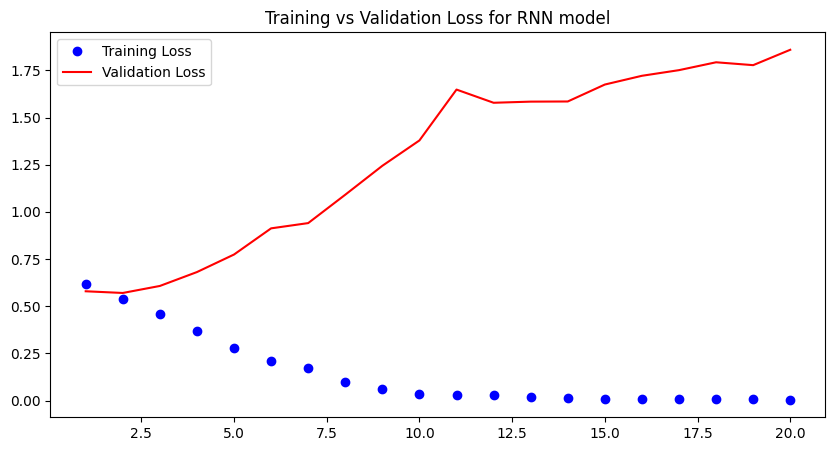

In [51]:
epochs = range(1, num_epochs + 1)
plt.figure(figsize=(10, 5))
plt.plot(epochs, RNN_losses["train_losses"], 'bo', label='Training Loss')
plt.plot(epochs, RNN_losses["valid_losses"], 'r', label='Validation Loss')
plt.title('Training vs Validation Loss for RNN model')
plt.legend()
plt.show()

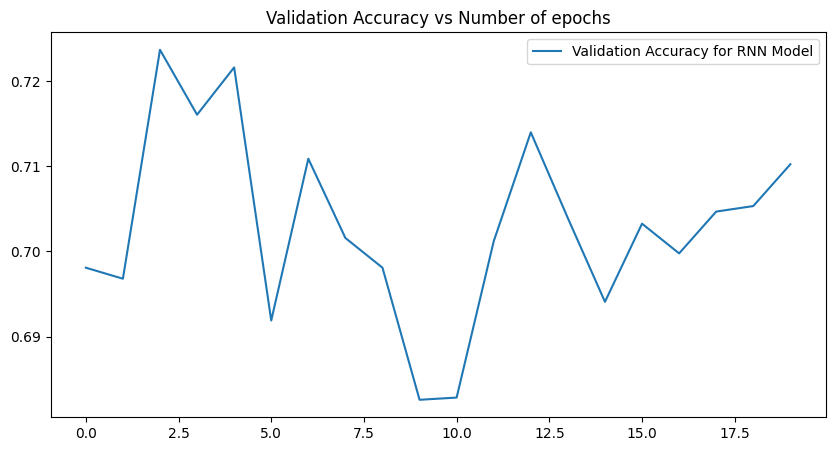

In [52]:
plt.figure(figsize=(10, 5))
plt.title("Validation Accuracy vs Number of epochs")
plt.plot(RNN_losses["valid_acc"], label="Validation Accuracy for RNN Model")
plt.legend()
plt.show()

Statistics for RNN model
Test loss 2.24
Test accuracy: 0.66
Test Precision: 0.92
Test Recall: 0.66
Test F1-score: 0.76
 


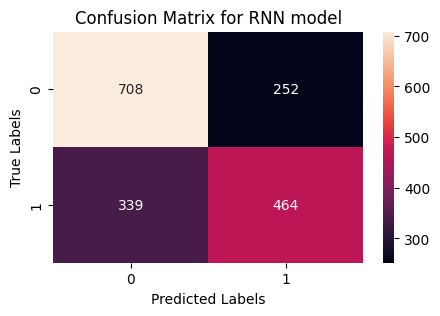

In [53]:
print("Statistics for RNN model")
print(f"Test loss {round(RNN_test_loss, 2)}")
print(f"Test accuracy: {round(RNN_test_acc, 2)}")
print(f"Test Precision: {round(RNN_test_precision, 2)}")
print(f"Test Recall: {round(RNN_test_recall, 2)}")
print(f"Test F1-score: {round(RNN_test_f1, 2)}")

print(" ")
fig, ax = plt.subplots(figsize=(5, 3))
sns.heatmap(RNN_test_cf, annot = True, fmt = '.0f')
ax.set_title(f'Confusion Matrix for RNN model')
ax.set_xlabel('Predicted Labels')
ax.set_ylabel('True Labels')
plt.show()